# PhilID Classifier Training (PyTorch MobileNetV2)

Train a binary ID classifier using PyTorch MobileNetV2 with transfer learning.

## Requirements
- PyTorch, torchvision, matplotlib, tqdm
- Training data in `../resources_online/id_classifier_cnn/data/`

## 1. Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.models import MobileNet_V2_Weights
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.10.0+cpu
CUDA available: False


## 2. Configuration

In [2]:
# Path to co-developer's data
DATA_DIR = "../../resources_online/id_classifier_cnn/data"

# Training config
CONFIG = {
    'img_size': 224,
    'batch_size': 16,  # Lower for CPU training
    'epochs': 15,
    'learning_rate': 0.001,
    'num_classes': 2,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

print(f"Data directory: {DATA_DIR}")
print(f"Using device: {CONFIG['device']}")
print(f"Training for {CONFIG['epochs']} epochs")

Data directory: ../../resources_online/id_classifier_cnn/data
Using device: cpu
Training for 15 epochs


## 3. Data Loading

In [3]:
# Data augmentation for training
train_transforms = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load datasets
train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), transform=train_transforms)
val_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'val'), transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Classes: {train_dataset.classes}")

Training samples: 21
Validation samples: 22
Classes: ['id', 'not_id']


## 4. Model Definition

In [4]:
class PhilIDClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.backbone = models.mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V2)
        
        # Freeze backbone
        for param in self.backbone.features.parameters():
            param.requires_grad = False
        
        # Custom classifier head
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        return self.backbone(x)
    
    def unfreeze_backbone(self, num_layers=5):
        layers = list(self.backbone.features.children())
        for layer in layers[-num_layers:]:
            for param in layer.parameters():
                param.requires_grad = True

model = PhilIDClassifier(num_classes=CONFIG['num_classes']).to(CONFIG['device'])
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to C:\Users\Jiwuu/.cache\torch\hub\checkpoints\mobilenet_v2-7ebf99e0.pth


100%|██████████████████████████████████████████████████████| 13.6M/13.6M [00:02<00:00, 5.88MB/s]

Trainable params: 164,226


## 5. Training

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])

def train_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(loader, desc="Training"):
        images, labels = images.to(CONFIG['device']), labels.to(CONFIG['device'])
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return total_loss / total, correct / total

def validate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(CONFIG['device']), labels.to(CONFIG['device'])
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return total_loss / total, correct / total

In [6]:
history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}
best_val_acc = 0.0

for epoch in range(CONFIG['epochs']):
    if epoch == 5:  # Unfreeze after 5 epochs
        print("\n>>> Unfreezing backbone layers...")
        model.unfreeze_backbone(5)
        optimizer = optim.Adam(model.parameters(), lr=CONFIG['learning_rate'] / 10)
    
    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss, val_acc = validate(model, val_loader)
    
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    
    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | Train: {train_acc:.3f} | Val: {val_acc:.3f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'model_state_dict': model.state_dict(),
            'class_mapping': train_dataset.class_to_idx,
            'classes': train_dataset.classes,
            'config': CONFIG
        }, '../app/models/philid_classifier.pt')
        print(f"  >>> Saved best model (acc: {val_acc:.3f})")

print(f"\nDone! Best val accuracy: {best_val_acc:.3f}")

Training: 100%|███████████████████████████████████████████████████| 2/2 [00:01<00:00,  1.17it/s]


Epoch 1/15 | Train: 0.571 | Val: 0.545
  >>> Saved best model (acc: 0.545)


Training: 100%|███████████████████████████████████████████████████| 2/2 [00:01<00:00,  1.56it/s]


Epoch 2/15 | Train: 0.714 | Val: 0.773
  >>> Saved best model (acc: 0.773)


Training: 100%|███████████████████████████████████████████████████| 2/2 [00:01<00:00,  1.96it/s]


...

Epoch 13/15 | Train: 1.000 | Val: 1.000


Training: 100%|███████████████████████████████████████████████████| 2/2 [00:01<00:00,  1.86it/s]


Epoch 14/15 | Train: 1.000 | Val: 1.000


Training: 100%|███████████████████████████████████████████████████| 2/2 [00:01<00:00,  1.84it/s]


Epoch 15/15 | Train: 1.000 | Val: 1.000

Done! Best val accuracy: 1.000


## 6. Results

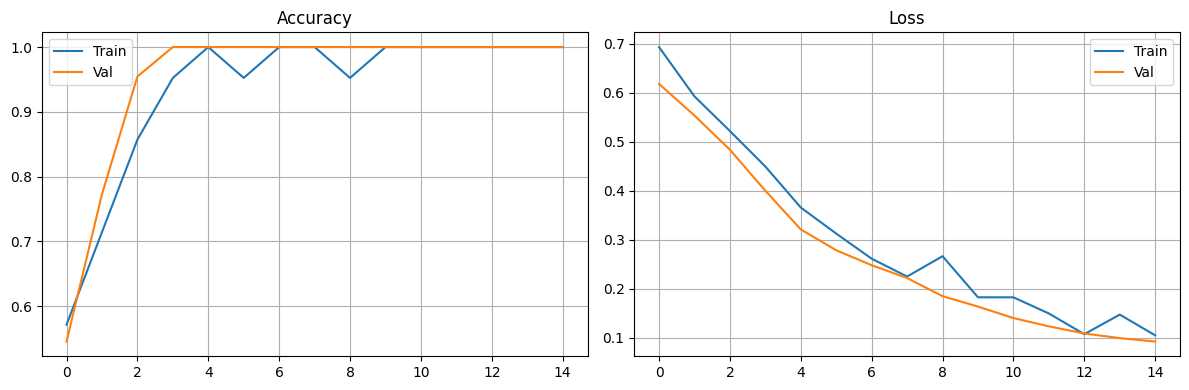


Model saved to: ../app/models/philid_classifier.pt


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_acc'], label='Train')
axes[0].plot(history['val_acc'], label='Val')
axes[0].set_title('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_loss'], label='Train')
axes[1].plot(history['val_loss'], label='Val')
axes[1].set_title('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('../app/models/training_history.png')
plt.show()

print("\nModel saved to: ../app/models/philid_classifier.pt")